## Import

In [11]:
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from titanic.data import load_processed_data
from titanic.selection import select_model_features, FEATURE_SETS
from titanic.preprocessing import preprocess_train_test
from titanic.models import get_baseline_models
from titanic.validation import benchmark_models

## Data loading

In [12]:
df = load_processed_data()

print(df.shape)
df.head()

(1309, 45)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,HasNickname,SexIsMale,IsAlone,HasFamily,FamilySize,TicketText,TicketNumber,TicketNumberClass,HasCabin,Deck,CabinNumber,CabinCount,SurnameValueCounts,FamilySizeValueCounts,CabinValueCounts,TicketValueCounts,FareValueCounts,FarePerTicketPassenger,FarePerTicketPassenger_log1p,GroupSize,GroupType,FarePerPerson,FarePerPerson_log1p,AgeETR,AgeGroup,AgeDecade,IsChild,FamilySurvivalRate,FamilySurvivalRateCount,TicketSurvivalRate,TicketSurvivalRateCount
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,1,0,1,2,A5,21171,2,0,NaN,NaN,0,2,235,NaN,1,18,7.25000,2.110213,2,couple,3.625000,1.531476,22.0,young_adult,20-29,0,0.319865,2.0,0.383838,1.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0,0,1,2,PC,17599,1,1,C,85.0,1,2,235,2.0,2,2,35.64165,3.601186,2,couple,35.641650,3.601186,38.0,adult,30-39,0,0.383838,1.0,0.383838,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0,1,0,1,STONO2,3101282,3,0,NaN,NaN,0,1,790,NaN,1,23,7.92500,2.188856,3,family,2.641667,1.292441,26.0,adult,20-29,0,0.383838,1.0,0.383838,1.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0,0,1,2,NaN,113803,1,1,C,123.0,1,2,235,2.0,2,6,26.55000,3.316003,2,couple,26.550000,3.316003,35.0,adult,30-39,0,0.319865,2.0,0.319865,2.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,1,1,0,1,NaN,373450,3,0,NaN,NaN,0,2,790,NaN,1,61,8.05000,2.202765,1,single,8.050000,2.202765,35.0,adult,30-39,0,0.486532,2.0,0.383838,1.0


In [13]:
train_df = df[df["Survived"].notna()].copy()
test_df = df[df["Survived"].isna()].copy()

print("train:", train_df.shape)
print("test:", test_df.shape)

train: (891, 45)
test: (418, 45)


In [14]:
df_model = select_model_features(
    df,
    #feature_set="base",
    include_target=True
)

features = [
    col for col in df_model.columns
    if col != "Survived"
]

features

['Pclass',
 'Title',
 'HasNickname',
 'AgeETR',
 'IsChild',
 'FamilySurvivalRate',
 'FarePerPerson_log1p',
 'TicketSurvivalRate',
 'HasCabin',
 'Deck']

## Preprocessing

In [15]:
X_train, y_train, X_test, preprocessor = preprocess_train_test(
    df_model,
    features=features,
    target="Survived",
    scale_numeric=True
)

feature_names = preprocessor.get_feature_names_out()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

X_train: (891, 20)
y_train: (891,)
X_test: (418, 20)


## Benchmark du feature set actuel

In [16]:
models = get_baseline_models(random_state=42)

benchmark_base = benchmark_models(
    models=models,
    X=X_train,
    y=y_train,
    scoring="accuracy",
    n_splits=10,
    random_state=42
)

benchmark_base

,model,train_score_mean,train_score_std,test_score_mean,test_score_std
0,SVC,0.869060,0.004360,0.851785,0.035978
1,GradientBoostingClassifier,0.908591,0.004955,0.850662,0.029525
2,AdaBoostClassifier,0.845990,0.003903,0.840612,0.021893
3,RandomForestClassifier,0.991645,0.000974,0.833833,0.034573
4,LogisticRegression,0.842748,0.003016,0.831610,0.022700
5,KNeighborsClassifier,0.877042,0.004858,0.828240,0.035708
6,XGBClassifier,0.979299,0.002801,0.826017,0.019779
7,ExtraTreesClassifier,0.991645,0.000974,0.819251,0.038270
8,BaggingClassifier,0.977179,0.002617,0.819226,0.048232
9,DecisionTreeClassifier,0.991645,0.000974,0.774332,0.047779


## Random Forest feature importance

In [17]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

rf_importance.head(30)

,feature,importance
0,num__FarePerPerson_log1p,0.190547
1,num__AgeETR,0.185854
2,cat__Title_Mr,0.166558
3,num__TicketSurvivalRate,0.111131
4,num__FamilySurvivalRate,0.080036
5,cat__Title_Miss,0.054095
6,num__Pclass,0.048373
7,num__HasNickname,0.045742
8,cat__Title_Mrs,0.043591
9,num__HasCabin,0.025802


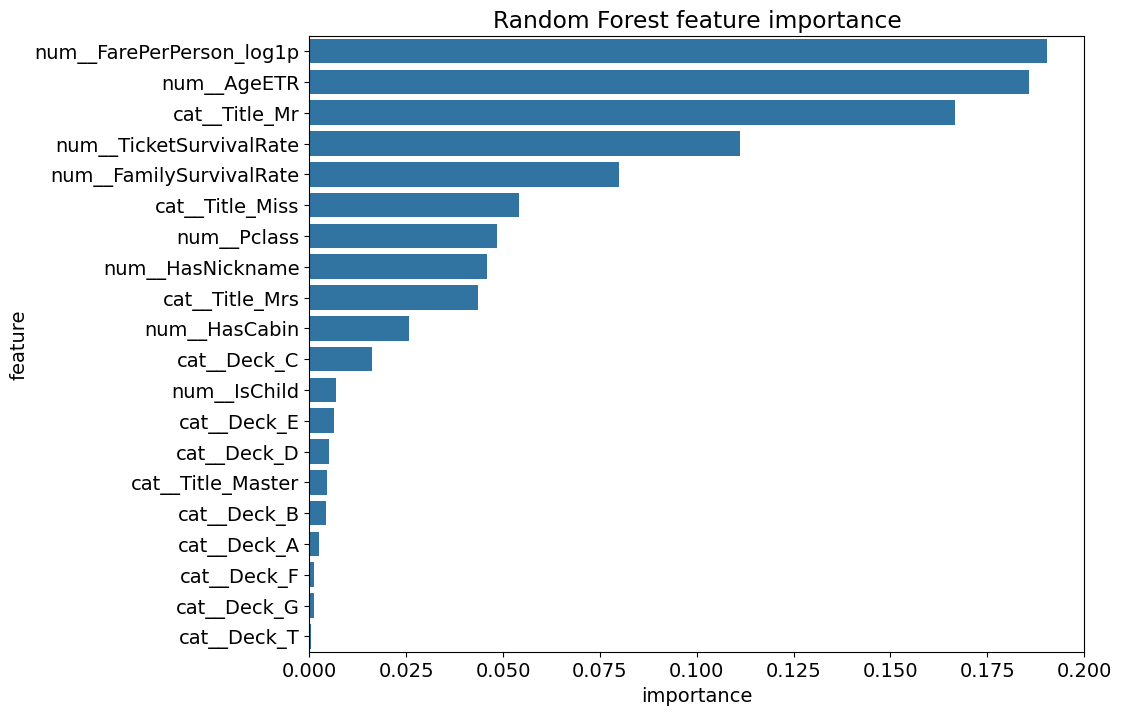

In [18]:
top_n = 25

plt.figure(figsize=(10, 8))

sns.barplot(
    data=rf_importance.head(top_n),
    x="importance",
    y="feature"
)

plt.title("Random Forest feature importance")
plt.show()

## Permutation importance

La permutation importance mesure une chose très simple :

Si je mélange aléatoirement une variable, combien le modèle perd-il en performance ?

Exemple avec AgeETR :

1. Le modèle a un score de départ.
2. On mélange uniquement la colonne AgeETR.
3. Les âges ne correspondent plus aux bons passagers.
4. On recalcule le score.
5. Si le score chute beaucoup, AgeETR était importante.

Donc :

importance_mean = perte moyenne de score
importance_std  = variabilité de cette perte

Dans ton cas :

FarePerPerson_log1p : 0.099

signifie grosso modo :

Si on casse FarePerPerson_log1p, le modèle perd environ 9.9 points d’accuracy.

C’est énorme.

In [19]:
perm = permutation_importance(
    rf,
    X_train,
    y_train,
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

perm_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

perm_importance.head(30)

,feature,importance_mean,importance_std
0,cat__Title_Mr,0.166330,0.009078
1,num__AgeETR,0.105948,0.005836
2,num__FarePerPerson_log1p,0.096783,0.006399
3,num__TicketSurvivalRate,0.064534,0.006504
4,num__Pclass,0.063113,0.006049
5,num__FamilySurvivalRate,0.043883,0.004243
6,num__HasNickname,0.036064,0.005278
7,num__HasCabin,0.023120,0.003752
8,cat__Title_Miss,0.015039,0.003075
9,cat__Deck_C,0.009951,0.002313


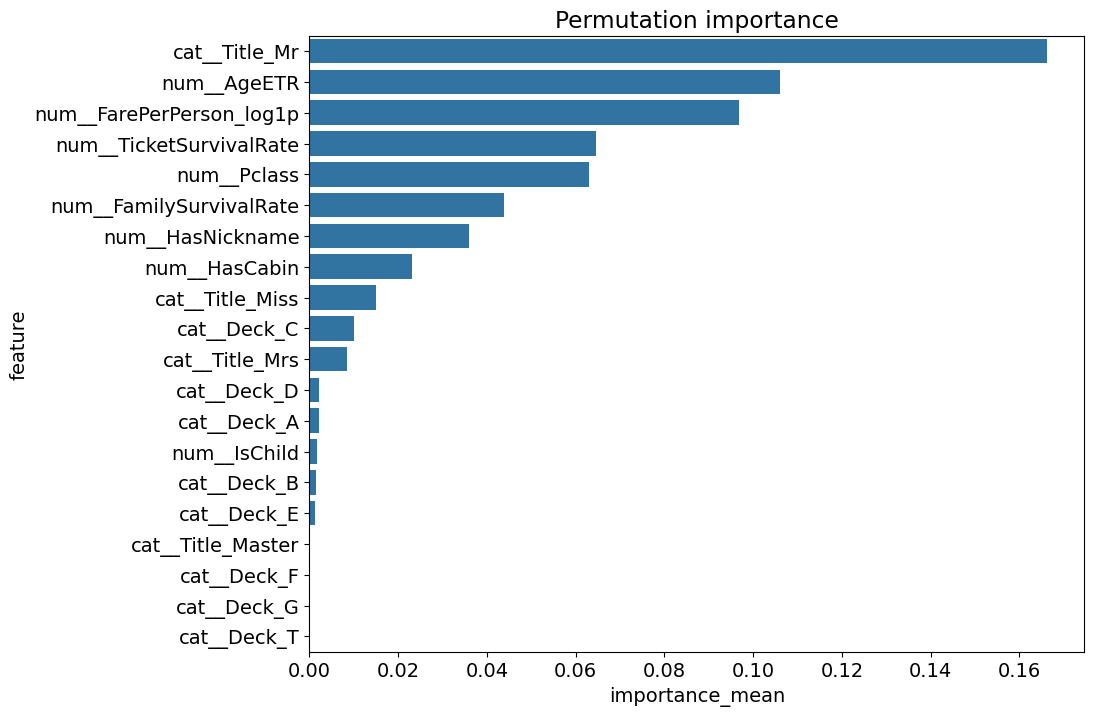

In [20]:
top_n = 25

plt.figure(figsize=(10, 8))

sns.barplot(
    data=perm_importance.head(top_n),
    x="importance_mean",
    y="feature"
)

plt.title("Permutation importance")
plt.show()

## Comparaison RF importance et permutation importance

In [21]:
importance_comparison = (
    rf_importance
    .merge(perm_importance, on="feature", how="left")
    .sort_values("importance_mean", ascending=False)
)

importance_comparison.head(30)

,feature,importance,importance_mean,importance_std
2,cat__Title_Mr,0.166558,0.166330,0.009078
1,num__AgeETR,0.185854,0.105948,0.005836
0,num__FarePerPerson_log1p,0.190547,0.096783,0.006399
3,num__TicketSurvivalRate,0.111131,0.064534,0.006504
6,num__Pclass,0.048373,0.063113,0.006049
4,num__FamilySurvivalRate,0.080036,0.043883,0.004243
7,num__HasNickname,0.045742,0.036064,0.005278
9,num__HasCabin,0.025802,0.023120,0.003752
5,cat__Title_Miss,0.054095,0.015039,0.003075
10,cat__Deck_C,0.016073,0.009951,0.002313


## Corrélation avec Survived

In [22]:
corr_with_target = (
    train_df
    .corr(numeric_only=True)["Survived"]
    .sort_values(ascending=False)
)

corr_with_target

Survived                        1.000000
HasNickname                     0.346496
TicketSurvivalRate              0.333668
HasCabin                        0.316912
FarePerPerson_log1p             0.307913
FarePerTicketPassenger_log1p    0.306219
FarePerTicketPassenger          0.288337
CabinCount                      0.283704
FarePerPerson                   0.259621
Fare                            0.257307
FamilySurvivalRate              0.236320
HasFamily                       0.203367
IsChild                         0.138047
CabinValueCounts                0.114854
Parch                           0.081629
TicketValueCounts               0.064962
TicketSurvivalRateCount         0.038247
FamilySize                      0.016639
PassengerId                    -0.005007
SurnameValueCounts             -0.025524
SibSp                          -0.035322
FamilySurvivalRateCount        -0.049188
AgeETR                         -0.061691
CabinNumber                    -0.063747
Age             

In [23]:
corr = train_df.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

strong_corr = (
    upper
    .stack()
    .reset_index()
)

strong_corr.columns = ["feature_1", "feature_2", "correlation"]

strong_corr = strong_corr.sort_values(
    "correlation",
    ascending=False
)

strong_corr.head(30)

,feature_1,feature_2,correlation
126,Age,AgeETR,1.000000
307,IsAlone,HasFamily,1.000000
315,IsAlone,FamilySizeValueCounts,0.985394
348,HasFamily,FamilySizeValueCounts,0.985394
591,SurnameValueCounts,FamilySurvivalRateCount,0.933447
692,TicketValueCounts,TicketSurvivalRateCount,0.931269
751,FarePerTicketPassenger,FarePerPerson,0.914193
143,SibSp,FamilySize,0.890712
478,HasCabin,CabinCount,0.886133
749,FarePerTicketPassenger,FarePerTicketPassenger_log1p,0.873967


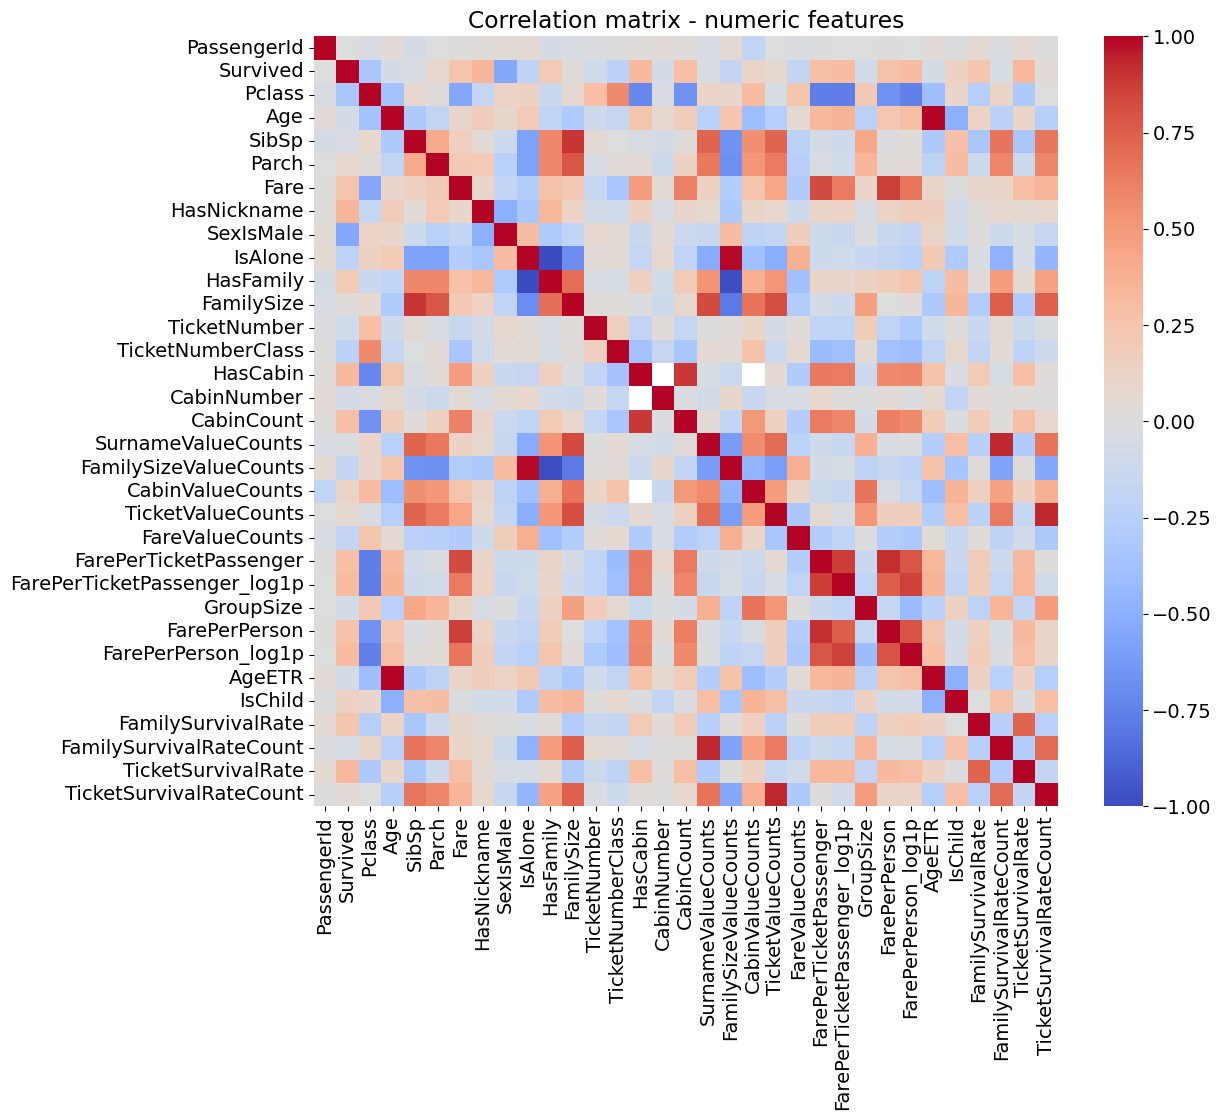

In [24]:
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12, 10))

sns.heatmap(
    train_df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix - numeric features")
plt.show()

## Fonction d’ablation study

In [27]:
from titanic.selection import select_model_features_set

def benchmark_feature_set(df, feature_set, model_name="SVC"):
    df_model = select_model_features_set(
        df,
        feature_set=feature_set,
        include_target=True
    )

    features = [
        col for col in df_model.columns
        if col != "Survived"
    ]

    X_train, y_train, X_test, preprocessor = preprocess_train_test(
        df_model,
        features=features,
        target="Survived",
        scale_numeric=True
    )

    models = get_baseline_models(random_state=42)

    benchmark = benchmark_models(
        models={model_name: models[model_name]},
        X=X_train,
        y=y_train,
        scoring="accuracy",
        n_splits=10,
        random_state=42
    )

    return {
        "feature_set": feature_set,
        "model": model_name,
        "score": benchmark.loc[0, "test_score_mean"],
        "std": benchmark.loc[0, "test_score_std"],
        "n_features_raw": len(features),
        "n_features_processed": X_train.shape[1]
    }

## Tester tous les feature sets existants

In [28]:
ablation_results = []

for feature_set in FEATURE_SETS.keys():
    result = benchmark_feature_set(
        df=df,
        feature_set=feature_set,
        model_name="SVC"
    )

    ablation_results.append(result)

ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

ablation_df

,feature_set,model,score,std,n_features_raw,n_features_processed
0,without_fare,SVC,0.838340,0.026883,11,30
1,without_family_raw,SVC,0.837203,0.035086,10,29
2,without_age,SVC,0.836092,0.025447,10,23
3,with_ticket,SVC,0.836092,0.026421,13,32
4,base,SVC,0.836092,0.029577,12,31
5,without_cabin,SVC,0.833858,0.025215,10,22
6,with_family,SVC,0.833858,0.025215,14,33
7,without_age_group,SVC,0.833845,0.029842,11,24
8,without_title,SVC,0.833845,0.029842,11,27
9,without_sex,SVC,0.833845,0.029842,11,30


## Tester plusieurs modèles sur les feature sets

In [29]:
model_names = [
    "SVC",
    "AdaBoostClassifier",
    "LogisticRegression",
    "GradientBoostingClassifier"
]

all_results = []

for feature_set in FEATURE_SETS.keys():
    for model_name in model_names:
        result = benchmark_feature_set(
            df=df,
            feature_set=feature_set,
            model_name=model_name
        )
        all_results.append(result)

feature_model_results = (
    pd.DataFrame(all_results)
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

feature_model_results

,feature_set,model,score,std,n_features_raw,n_features_processed
0,with_family,AdaBoostClassifier,0.842834,0.032709,14,33
1,without_fare,SVC,0.838340,0.026883,11,30
2,without_group,AdaBoostClassifier,0.837216,0.031253,11,27
3,without_family_raw,SVC,0.837203,0.035086,10,29
4,with_ticket,SVC,0.836092,0.026421,13,32
5,base,SVC,0.836092,0.029577,12,31
6,without_age,SVC,0.836092,0.025447,10,23
7,without_fare,AdaBoostClassifier,0.834969,0.035356,11,30
8,with_family,SVC,0.833858,0.025215,14,33
9,without_cabin,SVC,0.833858,0.025215,10,22


## Pivot de comparaison

In [30]:
feature_model_results.pivot_table(
    index="feature_set",
    columns="model",
    values="score"
).sort_values("SVC", ascending=False)

model,AdaBoostClassifier,GradientBoostingClassifier,LogisticRegression,SVC
feature_set,,,,
without_fare,0.834969,0.828227,0.821486,0.838340
without_family_raw,0.825993,0.830474,0.822597,0.837203
base,0.831598,0.829338,0.825980,0.836092
with_ticket,0.829401,0.828215,0.830449,0.836092
without_age,0.822634,0.822634,0.823745,0.836092
with_family,0.842834,0.830474,0.825980,0.833858
without_cabin,0.831623,0.821523,0.828227,0.833858
without_title,0.816991,0.827116,0.814744,0.833845
without_age_group,0.832722,0.823733,0.828215,0.833845


Les variables `FamilySurvivalRate` et `TicketSurvivalRate` introduisent une information issue des groupes familiaux et des tickets partagés.

Elles améliorent le score local, ce qui suggère que le destin des passagers n'est pas indépendant : les membres d'une même famille ou d'un même ticket ont souvent des probabilités de survie proches.

Ces variables sont conservées dans le feature set final.